# 定理1　苫米地主定理（個人 TCZ 収束）— 数値で見る例

> **この notebook の位置づけ。** ここで走らせるのは **数値シミュレーション（説明用のトイ例）** で、証明ではありません。
> 一般定理の前提を Lean で確かめた範囲は、最後の「Lean との対応」にまとめてあります。
> 「原文の主張」「この例が確認していること」「仏教的な読み（解釈）」は、見出しを分けて書きます。混同しないでください。

## 1. 定理1は何を言っているのか

### 原文の主張

心の状態を1つの点 $x$ で表し、「いま、どれくらい無理をしているか」を点数にする **評価関数** $V_0(x)$ を考えます（高いほどしんどい）。
点数が **しきい値 $\theta$ 以下** の範囲を **TCZ（トータル・コンフォート・ゾーン＝居心地のよい範囲）** と呼びます。

$$
\mathrm{TCZ}=\{x \mid V_0(x)\le \theta\}.
$$

Ego（意識的な自分）は「旅ぜんぶのしんどさの合計」を最小にする行動プラン $u(\cdot)$ を選びます。これが **最適制御方策** $\pi_c$ です。

$$
\pi_c=\arg\min_{u(\cdot)}\int V_0\bigl(x_u(s),s\bigr)\,ds .
$$

定理1（苫米地主定理）は、この $\pi_c$ を毎時刻解き直して使う（**反復ホライズン制御**）と、状態は居心地ゾーンへ **指数的に** 近づく、と主張します。

$$
\pi_c=\arg\min_{u(\cdot)}\int V_0\,ds\quad\Longrightarrow\quad \operatorname{dist}\bigl(x(t),\mathrm{TCZ}^{\mathrm{cl}}_1(t;x_0)\bigr)\longrightarrow 0 .
$$

ただし **前提** があります。原文は「argmin を解いているから収束する」とは言っていません（原文§3「厳密性」）。収束を保証するのは、次の **補題0（統一収束補題）** の条件です。

### 補題0（収束を保証する部品）

「はみ出し」$\Phi_1(x)=[V_0(x)-\theta]_+$（しきい値を超えた分。TCZ の中なら 0）を **残差** と呼びます。次の2条件が成り立つとします。

1. **下降条件**：残差が正のあいだ、$\dfrac{d}{dt}\Phi_1(x(t))\le -2c\,\Phi_1(x(t))$（ある $c>0$）。
2. **誤差境界**：$\operatorname{dist}(x,\mathrm{TCZ})^2\le C\,\Phi_1(x)$（ある $C>0$）。

このとき、$\Phi_1$ は指数的に 0 へ落ち（Grönwall の不等式）、距離も指数的に 0 へ向かいます。

$$
\operatorname{dist}\bigl(x(t),\mathrm{TCZ}\bigr)\;\le\;\sqrt{C\,\Phi_1(x_0)}\;e^{-ct}.
$$

定理1は「素の地形 $V_0$ にこの部品を当てはめただけ」であり、$\Phi_1\to0$ は「TCZ の中へ入る」の言い換えです。
**つまり本当に大事なのは「下降条件」が成り立つかどうか** で、argmin かどうかではありません。この notebook の (A)(B)(C) はそこを見せるための例です。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $x$ | 心の状態（ここでは1次元の実数） | `x` |
| $V_0(x)$ | 評価関数（しんどさの点数）。ここでは二重の谷 $(x^2-1)^2+0.3x$ | `V0` |
| $\theta$ | しきい値 | `theta = 0.0` |
| $\mathrm{TCZ}$ | $\{V_0\le\theta\}$（ここでは区間 $[-1.272,\,-0.730]$） | `tcz_lo, tcz_hi` |
| $\Phi_1$ | 残差 $[V_0-\theta]_+$ | `phi1` |
| $\operatorname{dist}(x,\mathrm{TCZ})$ | TCZ までの距離 | `dist_tcz` |
| $\pi_c$ | 合計コスト最小のプラン（の先頭だけ使う） | `receding_horizon` |
| ホライズン $T$ | 先を何秒ぶん見通して最小化するか | 引数 `T` |

## 2. なぜこれが「定理1の例」と言えるのか

* **地形**：$V_0$ は谷を2つ持ちます。左の谷（$x\approx-1.04$、$V_0\approx-0.31<0$）が TCZ の中、右の谷（$x\approx+0.96$、$V_0\approx+0.29>0$）は **TCZ の外にある局所谷** です。
  局所谷 = 「居心地は悪い（$V_0>\theta$）のに、まわりより低いので動けなくなる場所」です。
* **制御**：状態は $\dot x=u$（$|u|\le 1$）。各時刻に「ある目標点 $g$ まで全速で進み、着いたら止まる」というプランを多数比べて、先を $T$ だけ見たときのしんどさの合計 $\int V_0\,ds$ が最小のものを選び、**先頭の一歩だけ**進みます。これが反復ホライズン制御（原文の $\pi_c$）です。
  *注意：* 比べているのは「目標点へ直行するプラン」の族だけで、原文の「全ての許容制御での argmin」ではありません。
* **(A)** は下降条件が成り立つ状況（定理1の結論が見える例）、**(B)** は下降条件が破れる状況（argmin でも届かない反例）、**(C)** は (B) と同じ出発点でも見通しを伸ばすと届く例、**(D)** は Lean が実際に前提を検証した閉ループです。

## 3. 準備とシミュレーション

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

V0 = lambda x: (x**2 - 1)**2 + 0.3 * x
theta = 0.0
grid = np.linspace(-2, 2, 4001)
rts = np.roots([1, 0, -2, 0.3, 1]); rts = np.sort(rts[np.abs(rts.imag) < 1e-9].real)   # V0=0 の実根
tcz_lo, tcz_hi = rts[0], rts[1]               # TCZ = {V0 <= θ=0} = [tcz_lo, tcz_hi] (厳密な区間端)
dist_tcz = lambda x: max(tcz_lo - x, x - tcz_hi, 0.0)
phi1 = lambda x: max(V0(x) - theta, 0.0)       # 零残差 Φ1

TCZ の端点は $V_0(x)=0$ の実根で、$x\approx-1.2719,\ -0.7295$ です。距離 `dist_tcz` はこの区間までの距離です。

In [2]:
# %% 反復ホライズン制御: 各時刻で「目標点 g まで全速(|u|=1)で進み、着いたら停止」する
#    制御族を比較して ∫V0 ds が最小のものを選び、先頭 u(t+) だけ適用する。
#    (制御族を限った argmin。原文の全許容制御での argmin ではない点に注意)
def receding_horizon(x0, T, dt=0.05, steps=200):
    G = np.linspace(-2, 2, 161)
    s = np.arange(1, int(T / dt) + 1) * dt
    x, traj = x0, [x0]
    for _ in range(steps):
        path = x + np.sign(G - x)[:, None] * np.minimum(s[None, :], np.abs(G - x)[:, None])
        g = G[np.argmin(V0(path).sum(axis=1))]
        x = x + np.sign(g - x) * min(dt, abs(g - x))
        traj.append(x)
    return np.array(traj)

runs = {"(A) 左から出発, T=0.6": receding_horizon(-0.5, 0.6),
        "(B) 右の局所谷から, T=0.6": receding_horizon(1.5, 0.6),
        "(C) 右の局所谷から, T=8.0": receding_horizon(1.5, 8.0)}

ここでは3通りの走らせ方を作りました。
**(A)** 左の谷の近く（$x_0=-0.5$）から、見通し $T=0.6$。
**(B)** 右の局所谷（$x_0=1.5$）から、見通し $T=0.6$。
**(C)** (B) と同じ出発点で、見通し $T=8.0$。

## 4. 図を読む

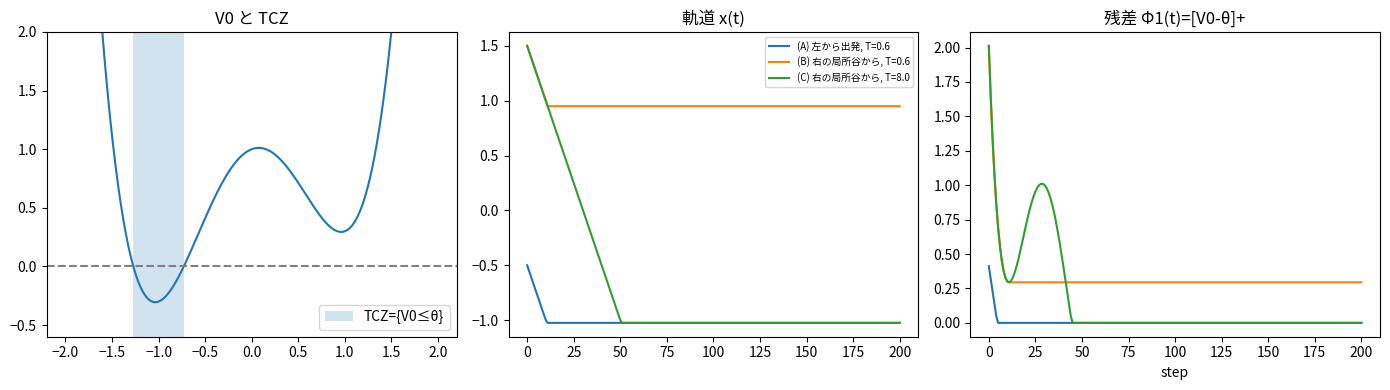

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(grid, V0(grid)); ax[0].axhline(theta, ls="--", c="gray")
ax[0].axvspan(tcz_lo, tcz_hi, alpha=.2, label="TCZ={V0≤θ}")
ax[0].set_ylim(-0.6, 2); ax[0].set_title("V0 と TCZ"); ax[0].legend()
for k, tr in runs.items():
    ax[1].plot(tr, label=k)
    ax[2].plot([phi1(x) for x in tr], label=k)
ax[1].set_title("軌道 x(t)"); ax[1].legend(fontsize=7)
ax[2].set_title("残差 Φ1(t)=[V0-θ]+"); ax[2].set_xlabel("step")
plt.tight_layout(); plt.show()

### 左：$V_0$ と TCZ

青い曲線が地形 $V_0$、灰色の破線が $\theta=0$、水色の帯が TCZ です。
**谷が2つ** あります。左の谷だけが破線より下（$V_0<\theta$）に入っていて、水色の帯はその部分です。右の谷は底でも約 $0.29$ で、破線より **上** です。つまり右の谷は居心地のよい範囲の外にあります。
2つの谷のあいだには山（$x\approx0.06$ で $V_0\approx1.01$）があります。

### 中央：軌道 $x(t)$

横軸はステップ（1ステップ $=0.05$ 秒、速度は最大 1）、縦軸は位置です。

* **青 (A)**：$-0.5$ から数ステップで左へ動いて、約 $-1.03$ で止まります。止まった位置は左の谷の底です（真の底は約 $-1.04$。候補の目標点を $0.025$ 刻みの格子で探しているので $-1.025$ になります）。
* **橙 (B)**：$1.5$ から左へ動き始めますが、約 $0.95$（右の局所谷の底）で **水平になって止まったまま** です。
* **緑 (C)**：$1.5$ から止まらずに左へ進み続け、約 50 ステップで $-1.03$ に着きます。山を **越えています**。

### 右：残差 $\Phi_1(t)=[V_0-\theta]_+$

* **青 (A)**：約 $0.41$（$=V_0(-0.5)$）から始まって、数ステップで 0 になります。0 になった時点で TCZ に入っています。
* **橙 (B)**：約 $0.29$ まで下がったあと、**ずっと $0.29$ のまま平ら** です。$\Phi_1>0$ なのに $\Phi_1'=0$ なので、補題0の **下降条件 $\Phi_1'\le-2c\Phi_1$ は破れています**。結論も成り立たず、TCZ までの距離は約 $1.68$ のままです。
* **緑 (C)**：いったん約 $0.29$ まで下がったあと、山に登るので **約 $1.0$ まで上がり**、その後 0 まで落ちます。

### 反例 (B) と回復 (C) の意味

(B) は「argmin を毎時刻解いているのに TCZ に届かない」例です。原文の言う通り、**argmin であること自体は収束を保証しません**。
理由は単純で、見通しが $T=0.6$ だと、動ける範囲は最大でも $0.6$ なので、山の向こうの深い谷が **見えません**。見える範囲では「いまの局所谷に留まる」のが合計コスト最小になってしまいます。

(C) は見通しを $T=8$ に伸ばすと山の向こうが見えるので、山を越えます。
ただし **(C) では $\Phi_1$ が途中で上がっています**。したがって補題0の下降条件が全区間で成り立っているわけではありません（コードのコメントにある「実質的に回復」は、「最終的に TCZ に届く」という意味にとどめて読んでください）。
この notebook (C) が確認しているのは「届いた」という数値の事実だけで、「定理1の前提を満たした」ことは (D) で確認します。

## 5. 数値確認

In [4]:
# %% 数値確認
for k, tr in runs.items():
    print(f"{k}: 最終 x={tr[-1]:+.3f}, dist(x,TCZ)={dist_tcz(tr[-1]):.3f}, Φ1={phi1(tr[-1]):.3f}")
assert dist_tcz(runs["(A) 左から出発, T=0.6"][-1]) < 1e-9
assert dist_tcz(runs["(B) 右の局所谷から, T=0.6"][-1]) > 1.0     # 反例: 届かない
assert dist_tcz(runs["(C) 右の局所谷から, T=8.0"][-1]) < 1e-9

(A) 左から出発, T=0.6: 最終 x=-1.025, dist(x,TCZ)=0.000, Φ1=0.000
(B) 右の局所谷から, T=0.6: 最終 x=+0.950, dist(x,TCZ)=1.680, Φ1=0.295
(C) 右の局所谷から, T=8.0: 最終 x=-1.025, dist(x,TCZ)=0.000, Φ1=0.000


(A) は終端で TCZ に入り（距離 0）、(B) は距離が $1$ を超えたまま、(C) は終端で TCZ に入ります。最後の3行の `assert` はこの3つを確認しています。

## 6. (D) 下降条件と誤差境界が成り立つ閉ループ

(B) のような「届かない」例と対照するため、**下降条件が成り立つ** 閉ループを1つ作ります。
目標点 $g=-1\in\mathrm{TCZ}$ に向かう目標点フィードバック $\dot x=-(x+1)$、出発点 $x_0=-\tfrac12$ です。厳密解は

$$
x(t)=-1+\tfrac12 e^{-t}.
$$

補題0の前提を次のパラメータで確かめます。

$$
c=\tfrac25,\qquad C=\tfrac16 .
$$

In [5]:
# %% (D) Lean が検証する閉ループ ẋ=-(x+1): 補題0の前提を数値でも確認
t = np.linspace(0, 6, 6001); xD = -1 + 0.5 * np.exp(-t)         # 厳密解 x(t)=-1+½e^{-t}
Phi = np.maximum(V0(xD), 0.0); dPhi = np.gradient(Phi, t)
inside = Phi > 1e-9
print("D: max(Φ'+2cΦ) (c=2/5, ≤0 なら下降条件) =", (dPhi + 0.8 * Phi)[inside][1:-1].max())
assert (dPhi + 0.8 * Phi)[inside][1:-1].max() < 1e-3
dist = np.array([dist_tcz(x) for x in xD])
assert np.all(dist**2 <= Phi / 6 + 1e-9)                          # 誤差境界 dist² ≤ Φ/6 (C=1/6)
assert np.all(dist <= np.sqrt(Phi[0] / 6) * np.exp(-0.4 * t) + 1e-9)   # 定理1の結論 dist ≤ √(CΦ0) e^{-ct}

D: max(Φ'+2cΦ) (c=2/5, ≤0 なら下降条件) = -0.4507589887573147


出力の「max(Φ'+2cΦ)」は $\Phi_1'+2c\Phi_1$ の最大値で、**負（約 $-0.45$）** です。これは $\Phi_1'\le-2c\,\Phi_1$ が TCZ の外で成り立っていることを意味します（下降条件）。
続く `assert` は、(i) 誤差境界 $\operatorname{dist}^2\le \Phi_1/6$、(ii) 定理1の結論の形 $\operatorname{dist}(x(t),\mathrm{TCZ})\le\sqrt{C\Phi_1(x_0)}\,e^{-ct}$ を、数値で確認しています。

## 7. 仏教的な意義（解釈）

> 以下は原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

定理1は四法印そのものではなく、その **土台** の定理です（「心は谷を転がるボールである」という地形の数学）。

* **評価関数 $V$ = しんどさの点数。** 原文は、$V$ を「Ego の運転を駆動するいのちのエンジン」と位置づけています（涅槃で消えるのはこの $V$ ではなく、残りの苦の合計 $J^*$ だ、という議論は定理26のところで出てきます）。
* **TCZ = 居心地のよい範囲。** 「苦」を点数で測り、点数がしきい値以下になる範囲を居心地の良さと呼びます。
* **局所谷 (B) の読み方の一例。** 局所谷は「いまの谷から出られない習慣的な状態」と読めます。見通しが短い（先を考えない）と、そこから動けない。見通しを伸ばす（先の世界が見える＝より高い抽象度で考える）と、山を越えられる。この「見通し＝抽象度」の話は、後の定理19・22（抽象度が上がるほど自由が増える）につながります。
  ただし (B)(C) は **見通しの長さだけの違い** を見る数値例で、「悟り」と同一視するものではありません。

## 8. Lean との対応（何が証明されていて、何がされていないか）

対応ファイル：`Tomabechi/Examples/Theorem1_DoubleWell.lean`（一般定理は `Theorem1.lean` 側）。

| | 内容 | 状態 |
| --- | --- | --- |
| (D) 目標点フィードバック $\dot x=-(x+1)$ | 補題0の前提（絶対連続・a.e. 下降 $c=\tfrac25$・誤差境界 $C=\tfrac16$）と、定理1の結論（指数評価）を、**一般定理から導いた** | 証明済 |
| (B) の反例側 | 右の局所谷の停留点（約 $0.95$）にとどまる定数軌道は、零フィードバックの閉ループの解で、**下降条件が破れて** 距離が正のまま | 証明済 |
| (A)(B)(C) の **反復ホライズン argmin の挙動そのもの** | 数値のみ | **未証明** |

* Lean が扱う閉ループは (D) です。もとの Python に (D) を足しました。反復ホライズンの argmin（目標点族の比較、格子 $0.025$、$dt=0.05$）の結果は、Lean では証明していません。
* 反例 (B) は「**定理の仮定を外した場合の挙動**」であり、原文の定理1そのものの反例ではありません。